In [1]:
# ================================================================
# HyperCLAP — Validation 1 : Stabilité Multi-Seeds
#
# Objectif : montrer que le résultat S11 (65% décomposition)
# n'est pas un artefact de la seed d'initialisation.
#
# Protocole : 3 runs identiques avec seeds 42, 123, 456
# Rapport   : mean ± std sur both-class accuracy (@2)
# ================================================================

In [2]:
!pip install -q datasets soundfile librosa
print("done")

done


In [6]:
import numpy as np
import librosa
import random
import warnings
warnings.filterwarnings("ignore")
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt
 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
 
CFG = dict(
    n_mels=128, n_fft=1024, hop_length=512,
    k=4, d=64, tau=0.1, lr=3e-4, batch_size=32,
)
TARGET_T   = 128
N_CLASSES  = 10
EPOCHS_P1  = 60
EPOCHS_P2  = 60
LAM        = 2.0
N_MIX_TEST = 400
SEEDS      = [42, 123, 456]

Device: cuda


In [4]:
# ── Helpers préprocessing ────────────────────────────────────────
def extract_logmel(sample):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    mel = librosa.feature.melspectrogram(
        y=w, sr=sr, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    return librosa.power_to_db(mel, ref=np.max)
 
def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32)
 
def pool_mel(t, T=TARGET_T):
    return F.adaptive_avg_pool2d(t.unsqueeze(0), (t.shape[0], T)).squeeze(0)
 
def normalize_w(w):
    n = np.linalg.norm(w); return w / n if n > 1e-8 else w

In [7]:
print("Loading ESC-50...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
 
all_logmels = []; all_waveforms = []; all_categories = []
for i, sample in enumerate(esc50_train):
    all_logmels.append(extract_logmel(sample))
    all_waveforms.append((sample["audio"]["array"], sample["audio"]["sampling_rate"]))
    all_categories.append(sample["category"])
    if (i+1) % 400 == 0: print(f"  {i+1}/{len(esc50_train)}")
 
categories    = sorted(set(all_categories))
cat2idx       = {c: i for i, c in enumerate(categories)}
all_label_ids = [cat2idx[c] for c in all_categories]
 
selected_classes = sorted(set(all_categories))[:N_CLASSES]
reduced_idx      = [i for i, c in enumerate(all_categories) if c in selected_classes]
reduced_logmels  = [all_logmels[i]   for i in reduced_idx]
reduced_wavs     = [all_waveforms[i] for i in reduced_idx]
reduced_labels   = [all_label_ids[i] for i in reduced_idx]
N_reduced        = len(reduced_idx)
print(f"Corpus: {N_reduced} clips, {N_CLASSES} classes\n")

Loading ESC-50...


Repo card metadata block was not found. Setting CardData to empty.


Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Corpus: 400 clips, 10 classes



In [8]:
# ── Architecture ────────────────────────────────────────────────
class SubspaceEncoder(nn.Module):
    def __init__(self, d=64, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024,256), nn.GELU(), nn.Linear(256, d*k))
    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x.unsqueeze(1)).view(B, -1)
        z = self.proj(h).view(B, self.d, self.k)
        Z, _ = torch.linalg.qr(z)
        return Z
 
class PointEncoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024,256), nn.GELU(), nn.Linear(256,d))
    def forward(self, x):
        B = x.shape[0]
        return F.normalize(self.proj(self.cnn(x.unsqueeze(1)).view(B,-1)), dim=-1)

In [9]:
# ── Losses ───────────────────────────────────────────────────────
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M**2).sum(dim=(2,3)) / Z1.shape[2]
 
def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1,2), Z2)
    return (M**2).sum(dim=(1,2)) / Z1.shape[2]
 
def infonce_subspace(Za, Zp, tau=0.1):
    B = Za.shape[0]
    return F.cross_entropy(subspace_sim_matrix(Za, Zp)/tau, torch.arange(B, device=Za.device))
 
def infonce_cosine(za, zp, tau=0.1):
    B = za.shape[0]
    return F.cross_entropy(torch.mm(za, zp.T)/tau, torch.arange(B, device=za.device))
 
def alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list, margin=0.1):
    pos = (subspace_sim_batch(Z_mix, Z_a) + subspace_sim_batch(Z_mix, Z_b)) / 2
    neg = torch.stack([subspace_sim_batch(Z_mix, Zn) for Zn in Z_neg_list], dim=1).max(1).values
    return F.relu(margin + neg - pos).mean(), pos.mean().item(), neg.mean().item()

In [10]:
# ── Datasets ─────────────────────────────────────────────────────
class PairDataset(Dataset):
    def __init__(self, logmels, label_ids):
        self.logmels = logmels; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self._t(idx), self._t(pos), label
 
class MixtureDataset(Dataset):
    def __init__(self, logmels, waveforms, label_ids, n_neg=4):
        self.logmels = logmels; self.waveforms = waveforms
        self.label_ids = label_ids; self.n_neg = n_neg
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
        self.all_classes = list(self.by_class.keys())
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def _mix_t(self, wa, sr_a, wb):
        mix = (normalize_w(wa) + normalize_w(wb)).astype(np.float32)
        lm  = librosa.feature.melspectrogram(y=mix, sr=sr_a,
            n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
        return pool_mel(logmel_to_tensor(librosa.power_to_db(lm, ref=np.max)))
    def __getitem__(self, idx):
        a_lbl  = self.label_ids[idx]
        others = [c for c in self.all_classes if c != a_lbl]
        b_idx  = random.choice(self.by_class[random.choice(others)])
        wa, sra = self.waveforms[idx]; wb, _ = self.waveforms[b_idx]
        negs   = [random.choice(self.by_class[random.choice(
                  [c for c in self.all_classes if c not in [a_lbl, self.label_ids[b_idx]]])])
                  for _ in range(self.n_neg)]
        return self._mix_t(wa, sra, wb), self._t(idx), self._t(b_idx), \
               torch.stack([self._t(n) for n in negs]), idx, b_idx

In [11]:
# ── Évaluation ───────────────────────────────────────────────────
def batch_sub_sim(z, mat):
    M = np.einsum("dp,ndq->npq", z, mat)
    return (M**2).sum(axis=(1,2)) / z.shape[1]
 
def batch_cos_sim(v, mat):
    return (mat @ v) / (np.linalg.norm(mat, axis=1) * np.linalg.norm(v) + 1e-8)
 
def orth_proj(Z_mix, Z_ref):
    P = np.eye(Z_mix.shape[0]) - Z_ref @ Z_ref.T
    Q, _ = np.linalg.qr(P @ Z_mix)
    return Q[:, :Z_mix.shape[1]]
 
def iterative_decomp(Z_mix, mat, ei, ej):
    s1 = batch_sub_sim(Z_mix, mat); s1[ei] = s1[ej] = -np.inf
    p1 = int(np.argmax(s1))
    s2 = batch_sub_sim(orth_proj(Z_mix, mat[p1]), mat)
    s2[ei] = s2[ej] = s2[p1] = -np.inf
    return p1, int(np.argmax(s2))
 
def evaluate(sub_model, pt_model, reduced_logmels, reduced_wavs,
             reduced_labels, N_reduced, N_CLASSES, N_MIX_TEST):
    sub_model.eval(); pt_model.eval()
    emb_sub = []; emb_pt = []
    with torch.no_grad():
        for lm in reduced_logmels:
            t = pool_mel(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)
            emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())
            emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())
    mat_sub = np.stack(emb_sub); mat_pt = np.stack(emb_pt)
 
    both_decomp = 0; both_pt = 0; n_q = 0
    for _ in range(N_MIX_TEST):
        i = random.randint(0, N_reduced-1); j = random.randint(0, N_reduced-1)
        if i == j: continue
        li = reduced_labels[i]; lj = reduced_labels[j]
        wa, sra = reduced_wavs[i]; wb, _ = reduced_wavs[j]
        mix = normalize_w(wa) + normalize_w(wb)
        lm_mix = librosa.feature.melspectrogram(y=mix, sr=sra,
            n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
        lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
        t_mix  = pool_mel(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()
            v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()
        ss = batch_sub_sim(Z_mix, mat_sub); ss[[i,j]] = -np.inf
        sp = batch_cos_sim(v_mix, mat_pt);  sp[[i,j]] = -np.inf
        p1, p2 = iterative_decomp(Z_mix, mat_sub, i, j)
        dl = {reduced_labels[p1], reduced_labels[p2]}
        top_pt = set([reduced_labels[idx] for idx in np.argsort(-sp)[:2]])
        n_q += 1
        if li in dl and lj in dl: both_decomp += 1
        if li in top_pt and lj in top_pt: both_pt += 1
 
    return both_decomp / n_q, both_pt / n_q

In [12]:
# ── Boucle multi-seeds ───────────────────────────────────────────
print("=" * 65)
print("VALIDATION 1 — Stabilité Multi-Seeds")
print(f"Seeds testées : {SEEDS}")
print("=" * 65)
 
results = []
 
for seed in SEEDS:
    print(f"\n{'─'*50}")
    print(f"SEED = {seed}")
    print(f"{'─'*50}")
 
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
 
    sub_model = SubspaceEncoder(d=CFG["d"], k=CFG["k"]).to(DEVICE)
    pt_model  = PointEncoder(d=CFG["d"]).to(DEVICE)
 
    pair_dl = DataLoader(PairDataset(reduced_logmels, reduced_labels),
                         batch_size=CFG["batch_size"], shuffle=True, drop_last=True)
    mix_dl  = DataLoader(MixtureDataset(reduced_logmels, reduced_wavs, reduced_labels),
                         batch_size=CFG["batch_size"], shuffle=True, drop_last=True)
 
    # Phase 1
    sub_opt = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"])
    pt_opt  = torch.optim.Adam(pt_model.parameters(),  lr=CFG["lr"])
    sub_model.train(); pt_model.train()
    for epoch in range(EPOCHS_P1):
        for anc, pos, _ in pair_dl:
            anc = anc.to(DEVICE); pos = pos.to(DEVICE)
            sub_opt.zero_grad()
            infonce_subspace(sub_model(anc), sub_model(pos), CFG["tau"]).backward()
            sub_opt.step()
            pt_opt.zero_grad()
            infonce_cosine(pt_model(anc), pt_model(pos), CFG["tau"]).backward()
            pt_opt.step()
        if (epoch+1) % 20 == 0:
            print(f"  P1 Epoch {epoch+1}/{EPOCHS_P1}")
 
    # Phase 2
    sub_opt2 = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"]/5)
    sub_model.train()
    for epoch in range(EPOCHS_P2):
        for mix_t, src_a, src_b, neg_ts, ai, bi in mix_dl:
            mix_t = mix_t.to(DEVICE); src_a = src_a.to(DEVICE)
            src_b = src_b.to(DEVICE); neg_ts = neg_ts.to(DEVICE)
            sub_opt2.zero_grad()
            Z_mix = sub_model(mix_t)
            with torch.no_grad():
                Z_a = sub_model(src_a); Z_b = sub_model(src_b)
                B, nn_, H, W = neg_ts.shape
                Zn = sub_model(neg_ts.view(B*nn_, H, W))
                Z_neg_list = [Zn[i::nn_] for i in range(nn_)]
            loss, _, _ = alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list)
            loss.backward(); sub_opt2.step()
        if (epoch+1) % 20 == 0:
            print(f"  P2 Epoch {epoch+1}/{EPOCHS_P2}")
 
    # Évaluation
    decomp_acc, pt_acc = evaluate(sub_model, pt_model,
                                   reduced_logmels, reduced_wavs,
                                   reduced_labels, N_reduced,
                                   N_CLASSES, N_MIX_TEST)
    ratio = decomp_acc / (pt_acc + 1e-8)
    results.append(dict(seed=seed, decomp=decomp_acc, pt=pt_acc, ratio=ratio))
    print(f"\n  Seed {seed} → Décomposition={decomp_acc:.4f}  Point={pt_acc:.4f}  Ratio={ratio:.1f}×")

VALIDATION 1 — Stabilité Multi-Seeds
Seeds testées : [42, 123, 456]

──────────────────────────────────────────────────
SEED = 42
──────────────────────────────────────────────────
  P1 Epoch 20/60
  P1 Epoch 40/60
  P1 Epoch 60/60
  P2 Epoch 20/60
  P2 Epoch 40/60
  P2 Epoch 60/60

  Seed 42 → Décomposition=0.6450  Point=0.1100  Ratio=5.9×

──────────────────────────────────────────────────
SEED = 123
──────────────────────────────────────────────────
  P1 Epoch 20/60
  P1 Epoch 40/60
  P1 Epoch 60/60
  P2 Epoch 20/60
  P2 Epoch 40/60
  P2 Epoch 60/60

  Seed 123 → Décomposition=0.6625  Point=0.0750  Ratio=8.8×

──────────────────────────────────────────────────
SEED = 456
──────────────────────────────────────────────────
  P1 Epoch 20/60
  P1 Epoch 40/60
  P1 Epoch 60/60
  P2 Epoch 20/60
  P2 Epoch 40/60
  P2 Epoch 60/60

  Seed 456 → Décomposition=0.5980  Point=0.1156  Ratio=5.2×



RÉSULTATS MULTI-SEEDS

  Seed       Décomposition      Point     Ratio
  ─────────────────────────────────────────────
  42                0.6450     0.1100      5.9×
  123               0.6625     0.0750      8.8×
  456               0.5980     0.1156      5.2×

  Mean  ± Std
    Décomposition : 0.6352 ± 0.0272
    Point encoder : 0.1002 ± 0.0180
    Ratio         : 6.6× ± 1.6×
    Random baseline: 0.2000

  Stabilité : ✓ Résultat stable (std < 0.10)

Figure saved → hyperclap_stability.png


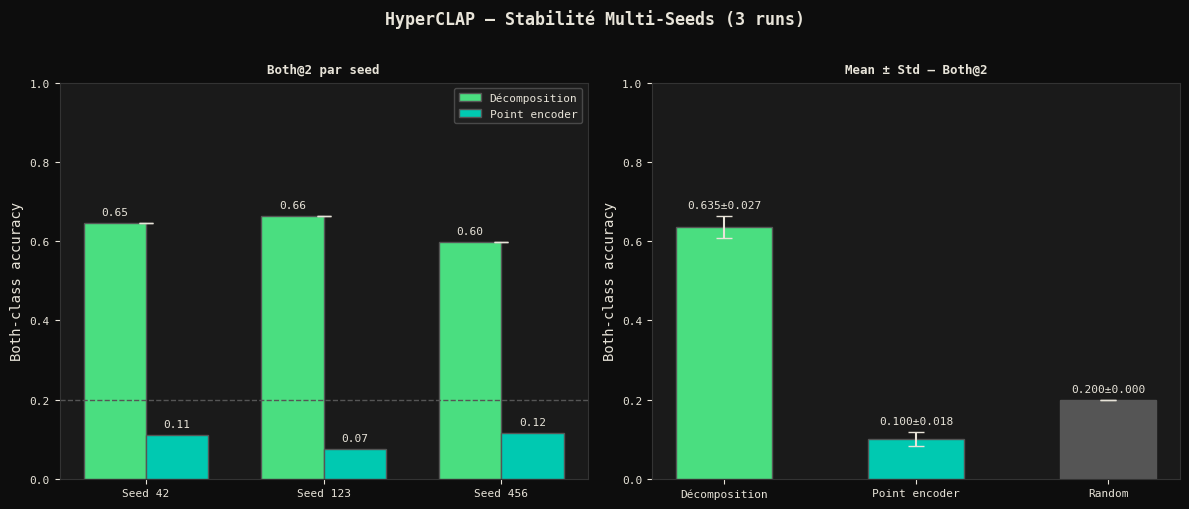

In [13]:
# ── Résultats ────────────────────────────────────────────────────
decomp_vals = [r["decomp"] for r in results]
pt_vals     = [r["pt"]     for r in results]
ratio_vals  = [r["ratio"]  for r in results]
 
print("\n" + "=" * 65)
print("RÉSULTATS MULTI-SEEDS")
print("=" * 65)
print(f"\n  {'Seed':<8} {'Décomposition':>15} {'Point':>10}  {'Ratio':>8}")
print("  " + "─" * 45)
for r in results:
    print(f"  {r['seed']:<8} {r['decomp']:>15.4f} {r['pt']:>10.4f}  {r['ratio']:>7.1f}×")
 
print(f"\n  Mean  ± Std")
print(f"    Décomposition : {np.mean(decomp_vals):.4f} ± {np.std(decomp_vals):.4f}")
print(f"    Point encoder : {np.mean(pt_vals):.4f} ± {np.std(pt_vals):.4f}")
print(f"    Ratio         : {np.mean(ratio_vals):.1f}× ± {np.std(ratio_vals):.1f}×")
print(f"    Random baseline: {2/N_CLASSES:.4f}")
 
stable = np.std(decomp_vals) < 0.10
print(f"\n  Stabilité : {'✓ Résultat stable (std < 0.10)' if stable else '✗ Variance élevée (std ≥ 0.10)'}")
 
# Figure
DARK="#0d0d0d"; LIGHT="#e8e4d9"; GREEN="#4ade80"; CYAN="#00c9b1"; ROSE="#ff5e78"
plt.rcParams.update({"text.color":LIGHT,"axes.labelcolor":LIGHT,
                     "xtick.color":LIGHT,"ytick.color":LIGHT,
                     "axes.edgecolor":"#333333","font.family":"monospace"})
def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a"); ax.set_title(title,color=LIGHT,fontsize=9,pad=7,fontweight="bold")
    ax.tick_params(colors=LIGHT,labelsize=8); ax.spines[:].set_color("#333333")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5)); fig.patch.set_facecolor(DARK)
 
ax = axes[0]; ax_style(ax, "Both@2 par seed")
x = np.arange(len(SEEDS)); w = 0.35
ax.bar(x-w/2, decomp_vals, w, color=GREEN, edgecolor="#555", label="Décomposition")
ax.bar(x+w/2, pt_vals,     w, color=CYAN,  edgecolor="#555", label="Point encoder")
ax.axhline(2/N_CLASSES, color="#555", ls="--", lw=1)
ax.errorbar([0,1,2], decomp_vals,
            yerr=[0,0,0], fmt='none', color=LIGHT, capsize=5)
ax.set_xticks(x); ax.set_xticklabels([f"Seed {s}" for s in SEEDS])
ax.set_ylabel("Both-class accuracy"); ax.set_ylim(0, 1.0)
ax.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
for i_, (d, p) in enumerate(zip(decomp_vals, pt_vals)):
    ax.text(i_-w/2, d+0.02, f"{d:.2f}", ha="center", color=LIGHT, fontsize=8)
    ax.text(i_+w/2, p+0.02, f"{p:.2f}", ha="center", color=LIGHT, fontsize=8)
 
ax2 = axes[1]; ax_style(ax2, "Mean ± Std — Both@2")
methods = ["Décomposition", "Point encoder", "Random"]
means   = [np.mean(decomp_vals), np.mean(pt_vals), 2/N_CLASSES]
stds    = [np.std(decomp_vals),  np.std(pt_vals),  0]
colors  = [GREEN, CYAN, "#555"]
ax2.bar(methods, means, color=colors, edgecolor="#555", width=0.5,
        yerr=stds, capsize=6, error_kw=dict(ecolor=LIGHT, lw=1.5))
ax2.set_ylabel("Both-class accuracy"); ax2.set_ylim(0, 1.0)
for i_, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i_, m+s+0.02, f"{m:.3f}±{s:.3f}", ha="center", color=LIGHT, fontsize=8)
 
fig.suptitle("HyperCLAP — Stabilité Multi-Seeds (3 runs)",
             color=LIGHT, fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/hyperclap_stability.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("\nFigure saved → hyperclap_stability.png")
plt.show()